In [31]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [220]:
import pandas as pd
import numpy as np
import pyreadstat
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats
from statsmodels.stats.power import FTestAnovaPower
from pathlib import Path
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from scipy.stats import shapiro
from scipy.stats import boxcox
from statsmodels.stats.multicomp import pairwise_tukeyhsd



In [108]:
# utilities

def _define_plot_style(title='', xlabel='', ylabel='', figsize=(4, 6)):
    plt.style.use('_mpl-gallery')
    fig, ax = plt.subplots(figsize=figsize)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, linestyle='--', alpha=0.5)
    return fig, ax


def save_and_display_plot(path):
    """
    Save the figure to the specified path.
    """
    filepath = Path(path)
    plt.savefig(filepath, format='pdf', bbox_inches='tight')
    plt.show()


In [24]:
df, meta = pyreadstat.read_sav('BD_MI_II_2024_25.sav')
# Uncomment the next line to see the entire dataframe
#with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.precision', 3):
#    display(df)

# uncomment the next line to see only the first 5 rows (Helpful just to check the type of data on each column)
# df.head()

len(df)


226

In [16]:
# Group by age to check how many responses we have for each age
df.groupby(['idade'])['idade'].count()

idade
18.0    10
19.0    28
20.0    77
21.0    52
22.0    17
23.0    13
24.0     7
25.0     6
26.0     2
27.0     1
29.0     1
30.0     1
31.0     2
32.0     1
35.0     1
41.0     1
47.0     1
48.0     1
57.0     1
Name: idade, dtype: int64

In [206]:
# Ages have very unbalanced group sizes, especially at the tail ends (only 1 or 2 people for more than 26 years).
# the best thing to do is to combine groups to create more balanced groups for ANOVA.

group_a = df[df['idade'] <= 19]
group_b = df[(df['idade'] >= 20) & (df['idade'] <= 21)]
group_c = df[df['idade'] >= 22]
group_na = df[df['idade'].isna()]

print(f'Group A: {len(group_a)}')
print(f'Group B: {len(group_b)}')
print(f'Group C: {len(group_c)}')
print(f'Group NA: {len(group_na)}')

# The groups are:
# A - 18-19 years (19 or less) - 38 responses
# B - 20-21 years (20-21) - 129 responses
# C - 22-27 years (22 plus) - 56 responses
# No Response - 3 responses - Given this represents only 1,3% of the total sample, we can ignore this group for the analysis.

Group A: 38
Group B: 129
Group C: 56
Group NA: 3
Group BA: 77
Group BB: 52


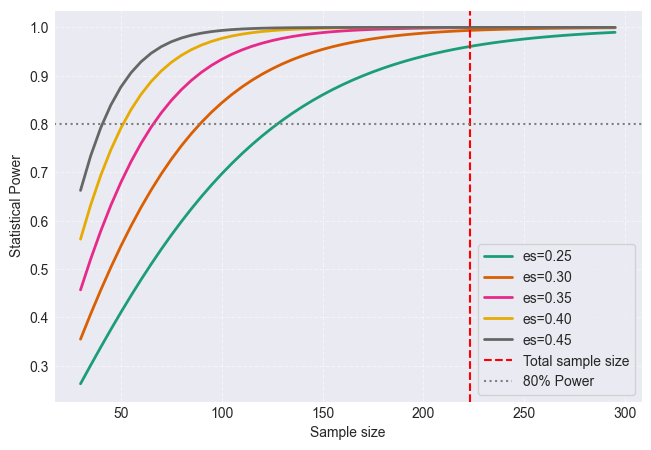

In [120]:
# Let's run a power analysis to check if this distribution is significant enough to run ANOVA
# The power analysis will be run with the following parameters: Cohen f = 0.25, alpha = 0.05, power = 0.8, number of groups = 3

# Parameters
effect_size = 0.25       # medium effect size
alpha = 0.05             # significance level
power = 0.8              # desired power

group_sizes = [len(group_a), len(group_b), len(group_c)]
k_groups = len(group_sizes)  # number of groups


# Range of total sample sizes
total_sample_sizes = np.arange(30, 300, 5)


# Plot power curve for total sample size
fig, ax = _define_plot_style(xlabel='Sample size', ylabel='Statistical Power', figsize=(6, 4))
power_analysis = FTestAnovaPower()
power_analysis.plot_power(dep_var='nobs',
                          nobs=total_sample_sizes,
                          effect_size=np.arange(effect_size, 0.5, 0.05),
                          alpha=0.05, ax=ax)

plt.title('')
plt.xlabel('Sample size')
# Add vertical line for harmonic mean
plt.axvline(sum(group_sizes), color='red', linestyle='--', label=f'Total sample size')
plt.axhline(y=0.8, color='gray', linestyle=':', label='80% Power')

plt.legend()
save_and_display_plot('../figures/anova/PowerGraph_total_sample.pdf')


Harmonic mean sample size: 57.78


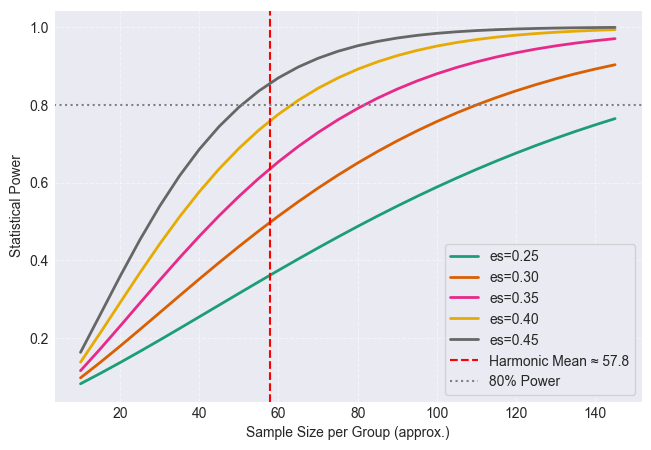

Statistical power: 0.9233965479697834


In [124]:

effect_size = 0.25
alpha = 0.05
power = 0.8

analysis = FTestAnovaPower()

# Calculate harmonic mean
harmonic_n = k_groups / sum(1 / n for n in group_sizes)
print(f'Harmonic mean sample size: {harmonic_n:.2f}')

# Create power plot around the harmonic mean
nobs_list = np.arange(10, 150, 5)

# Plot power curve
fig, ax = _define_plot_style(figsize=(6, 4))
power_analysis = FTestAnovaPower()
power_analysis.plot_power(dep_var='nobs',
                          nobs=nobs_list,
                          effect_size=np.arange(effect_size, 0.5, 0.05),  # medium effect
                          alpha=0.05,
                          k_groups=k_groups, ax=ax)

# Add vertical line for harmonic mean
plt.axvline(harmonic_n, color='red', linestyle='--', label=f'Harmonic Mean ≈ {harmonic_n:.1f}')
plt.axhline(y=0.8, color='gray', linestyle=':', label='80% Power')

plt.title('')
plt.xlabel('Sample Size per Group (approx.)')
plt.ylabel('Statistical Power')
plt.legend()
save_and_display_plot('../figures/anova/PowerGraph_harmonic_mean.pdf')

power_1 = analysis.power(effect_size=0.25, nobs=sum(group_sizes), alpha=0.05, k_groups=len(group_sizes))
print(f'Statistical power: {power_1}')


In [130]:
age_and_dass_columns = ['idade'] + [col for col in df.columns if col.startswith('DASS_')]
stress_columns = ['DASS_1', 'DASS_6', 'DASS_8', 'DASS_11', 'DASS_12', 'DASS_14', 'DASS_18']
axiety_columns = ['DASS_2', 'DASS_4', 'DASS_7', 'DASS_9', 'DASS_12', 'DASS_15', 'DASS_19', 'DASS_20']
depression_columns = ['DASS_3', 'DASS_5', 'DASS_10', 'DASS_13', 'DASS_16', 'DASS_17', 'DASS_21']

group_bellow_19 = df[df['idade'] <= 19][age_and_dass_columns]
group_20_21 = df[(df['idade'] >= 20) & (df['idade'] <= 21)][age_and_dass_columns]
group_above_22 = df[df['idade'] >= 22][age_and_dass_columns]

groups = {'group_bellow_19': group_bellow_19, 'group_20_21': group_20_21, 'group_above_22': group_above_22}

groups_by_dass = {
    'depression': {
        'group_bellow_19': group_bellow_19[['idade'] + depression_columns],
        'group_20_21': group_20_21[['idade'] + depression_columns],
        'group_above_22': group_above_22[['idade'] + depression_columns]
    },
    'anxiety': {
        'group_bellow_19': group_bellow_19[['idade'] + axiety_columns],
        'group_20_21': group_20_21[['idade'] + axiety_columns],
        'group_above_22': group_above_22[['idade'] + axiety_columns]
    },
    'stress': {
        'group_bellow_19': group_bellow_19[['idade'] + stress_columns],
        'group_20_21': group_20_21[['idade'] + stress_columns],
        'group_above_22': group_above_22[['idade'] + stress_columns]
    }
}

# dealing with missing data
# https://scikit-learn.org/stable/modules/impute.html

# estimator = RandomForestRegressor(n_estimators=4, max_depth=10, bootstrap=True, max_samples=0.5, n_jobs=2, random_state=0)
imp = IterativeImputer(max_iter=10, random_state=0)
for key in groups_by_dass.keys():
    for group_key, group_value in groups_by_dass[key].items():
        imp.fit(group_value)
        groups_by_dass[key][group_key] = pd.DataFrame(np.round(imp.transform(group_value))).set_axis(group_value.columns, axis=1)
        # add score column
        groups_by_dass[key][group_key]['score'] = groups_by_dass[key][group_key].sum(axis=1)


/Users/ricardo.ferreira/.pyenv/versions/forms/lib/python3.12/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ricardo.ferreira/.pyenv/versions/forms/lib/python3.12/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


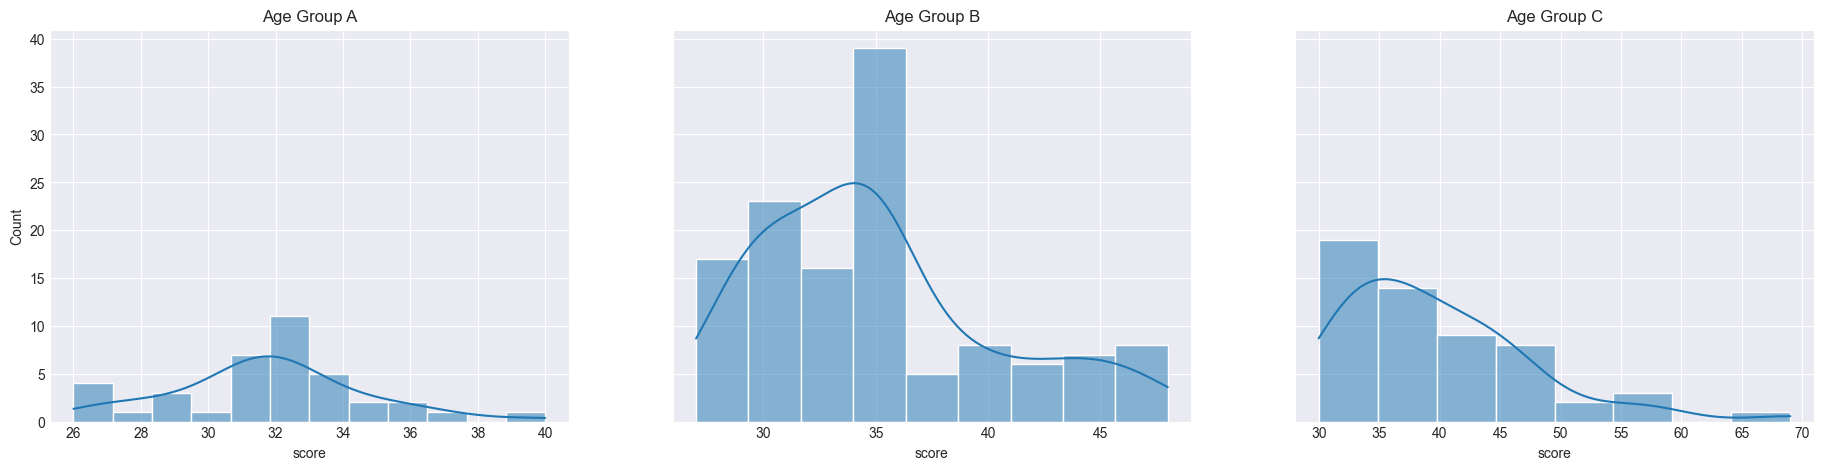

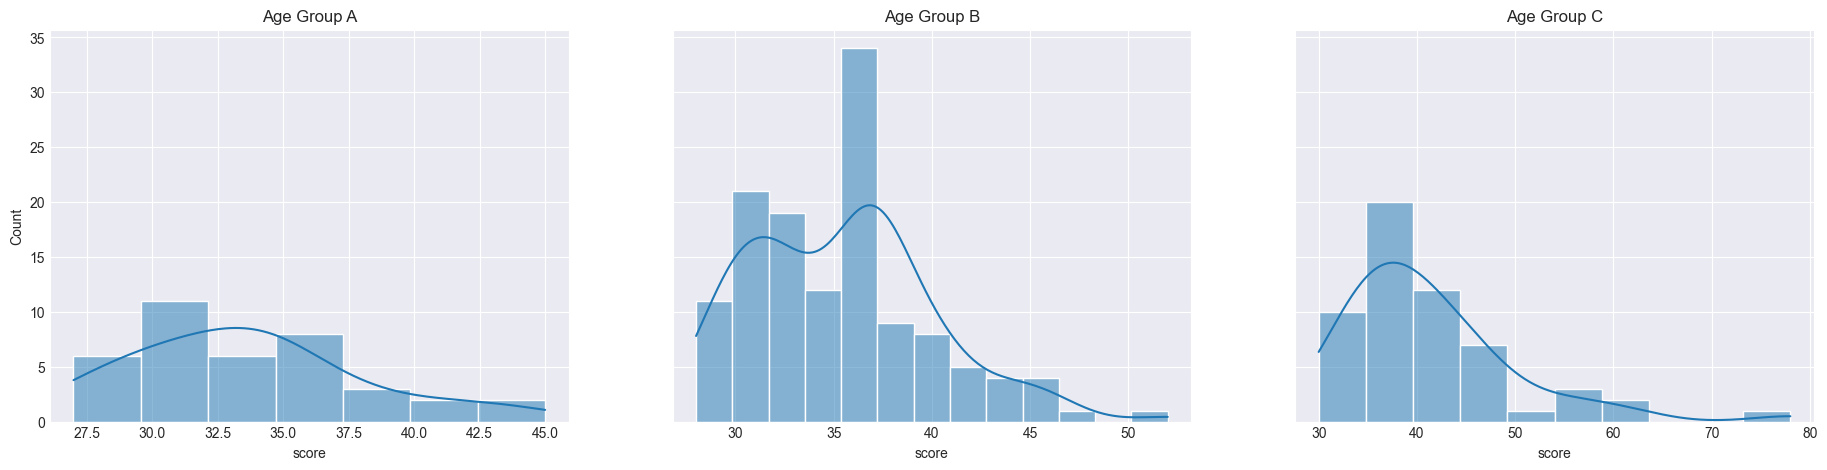

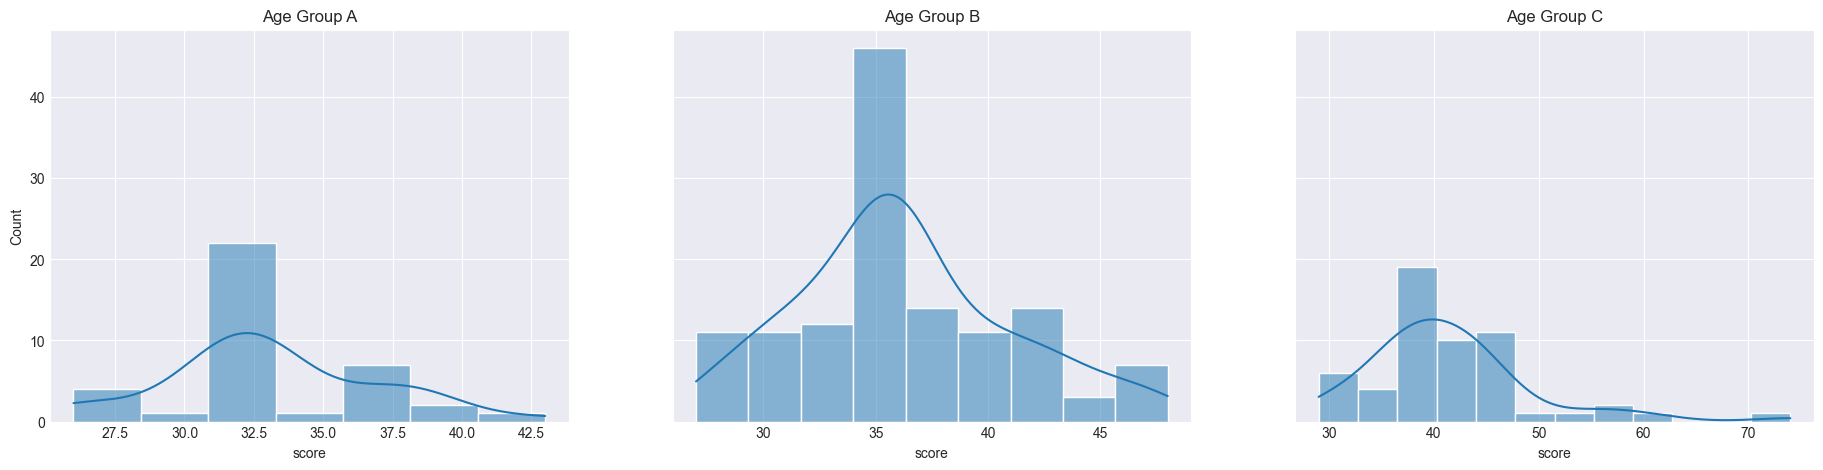

In [147]:
# Plot normality score

dass_scales = ['depression', 'anxiety', 'stress']
age_groups = ['group_bellow_19', 'group_20_21', 'group_above_22']

for dass_scale in dass_scales:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
    fig.subtitle = 'DASS Depression'
    sns.histplot(data=groups_by_dass[dass_scale]['group_bellow_19'], x='score', kde=True, ax=axes[0])
    axes[0].set_title('Age Group A')
    axes[0].set_xlabel("score")
    sns.histplot(data=groups_by_dass[dass_scale]['group_20_21'], x='score', kde=True, ax=axes[1])
    axes[1].set_title('Age Group B')
    axes[1].set_xlabel("score")
    sns.histplot(data=groups_by_dass[dass_scale]['group_above_22'], x='score', kde=True, ax=axes[2])
    axes[2].set_title('Age Group C')
    axes[2].set_xlabel("score")
    filepath = Path('../figures/anova/' + dass_scale + '_distribution.pdf')
    plt.savefig(filepath, format='pdf', bbox_inches='tight')



In [153]:
# Shapiro-Wilk test for normality
for dass_scale in dass_scales:
    for age_group in age_groups:
        shapiro_stat, shapiro_p = shapiro(groups_by_dass[dass_scale][age_group]['score'])
        print(f'{dass_scale}-{age_group} results: {shapiro_stat, shapiro_p}')


depression-group_bellow_19 results: (0.9525491341793115, 0.10807098067251449)
depression-group_20_21 results: (0.9169501857628923, 7.460526770044049e-07)
depression-group_above_22 results: (0.8844031304543654, 6.472546916179001e-05)
anxiety-group_bellow_19 results: (0.9478861239316816, 0.07585698215006896)
anxiety-group_20_21 results: (0.9507402260873905, 0.00013763817753087033)
anxiety-group_above_22 results: (0.8544787717907281, 7.74041742640754e-06)
stress-group_bellow_19 results: (0.9342420520631366, 0.027342353150019913)
stress-group_20_21 results: (0.9690433388188086, 0.004760242764426171)
stress-group_above_22 results: (0.8739605977025058, 2.9954061228817218e-05)


In [203]:
# Transform data using the boxcox transformation
for dass_scale in dass_scales:
    for age_group in age_groups:
        # Check if the data is positive
        if (groups_by_dass[dass_scale][age_group]['score'] <= 0).any():
            print(f"Data for {dass_scale} - {age_group} contains non-positive values. Box-Cox transformation cannot be applied.")
        else:
            # Apply Box-Cox transformation
            transformed_data, lambda_value = boxcox(groups_by_dass[dass_scale][age_group]['score'])
            groups_by_dass[dass_scale][age_group]['transformed_score'] = transformed_data
            print(f'Box-Cox transformation applied to {dass_scale} - {age_group} with lambda = {lambda_value}')



Box-Cox transformation applied to depression - group_bellow_19 with lambda = -0.07983806268151833
Box-Cox transformation applied to depression - group_20_21 with lambda = -1.7760630464657148
Box-Cox transformation applied to depression - group_above_22 with lambda = -1.9229061268402676
Box-Cox transformation applied to anxiety - group_bellow_19 with lambda = -1.1055974697023474
Box-Cox transformation applied to anxiety - group_20_21 with lambda = -0.9951023764323427
Box-Cox transformation applied to anxiety - group_above_22 with lambda = -1.9105166794056876
Box-Cox transformation applied to stress - group_bellow_19 with lambda = 0.24575449535355773
Box-Cox transformation applied to stress - group_20_21 with lambda = -0.23140735199694756
Box-Cox transformation applied to stress - group_above_22 with lambda = -1.1188504023470973


In [205]:
# Shapiro-Wilk test for normality
for dass_scale in dass_scales:
    for age_group in age_groups:
        shapiro_stat, shapiro_p = shapiro(groups_by_dass[dass_scale][age_group]['transformed_score'])
        print(f'{dass_scale}-{age_group} results: {round(shapiro_stat, 4), round(shapiro_p, 4)}')


depression-group_bellow_19 results: (0.957, 0.1518)
depression-group_20_21 results: (0.9655, 0.0023)
depression-group_above_22 results: (0.9724, 0.2269)
anxiety-group_bellow_19 results: (0.9711, 0.4209)
anxiety-group_20_21 results: (0.9693, 0.005)
anxiety-group_above_22 results: (0.9902, 0.929)
stress-group_bellow_19 results: (0.9357, 0.0303)
stress-group_20_21 results: (0.9799, 0.052)
stress-group_above_22 results: (0.9693, 0.1629)


In [208]:
# Variance test (Levene's test)
for dass_scale in dass_scales:
    levene_stat, levene_p = stats.levene(groups_by_dass[dass_scale]['group_bellow_19']['score'].unique(),
                                        groups_by_dass[dass_scale]['group_20_21']['score'].unique(),
                                        groups_by_dass[dass_scale]['group_above_22']['score'].unique())
    print(f'{dass_scale} Levene\'s test results: {round(levene_stat, 4), round(levene_p, 4)}')


depression Levene's test results: (3.7803, 0.0292)
anxiety Levene's test results: (3.4976, 0.0367)
stress Levene's test results: (2.8127, 0.0689)


In [236]:
group_a_scores = groups_by_dass['stress']['group_bellow_19'][['score']]
group_a_scores.insert(0, 'group', 'group_bellow_19')
group_b_scores = groups_by_dass['stress']['group_20_21'][['score']]
group_b_scores.insert(0, 'group', 'group_20_21')
group_c_scores = groups_by_dass['stress']['group_above_22'][['score']]
group_c_scores.insert(0, 'group', 'group_above_22')
combined_stress_scores = pd.concat([group_a_scores, group_b_scores, group_c_scores], ignore_index=True)
combined_stress_scores


,group,score
0,group_bellow_19,31.0
1,group_bellow_19,37.0
2,group_bellow_19,33.0
3,group_bellow_19,26.0
4,group_bellow_19,32.0
...,...,...
218,group_above_22,45.0
219,group_above_22,36.0
220,group_above_22,42.0
221,group_above_22,38.0


In [215]:
model = ols('score ~ group', data=combined_stress_scores).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)


               sum_sq     df          F        PR(>F)
group     1728.835108    2.0  27.120712  2.963868e-11
Residual  7012.052785  220.0        NaN           NaN


In [232]:
f_dep, p_dep = stats.f_oneway(groups_by_dass['stress']['group_bellow_19']['score'], groups_by_dass['stress']['group_20_21']['score'], groups_by_dass['stress']['group_above_22']['score'])
p_dep


2.963868397202223e-11

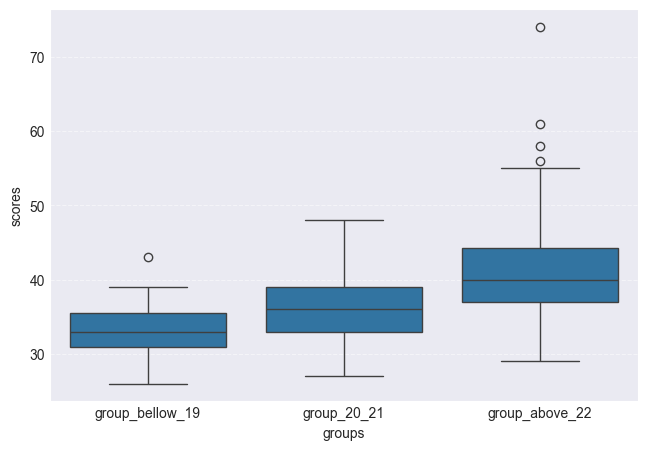

In [230]:
_define_plot_style(title='', xlabel='groups', ylabel='scores', figsize=(6, 4))
sns.boxplot(x='group', y='score', data=combined_stress_scores)
save_and_display_plot('../figures/anova/StressBoxPlot.pdf')


In [223]:
res = stats.tukey_hsd(groups_by_dass['stress']['group_bellow_19']['score'], groups_by_dass['stress']['group_20_21']['score'], groups_by_dass['stress']['group_above_22']['score'])
print(res)


Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -3.104     0.009    -5.563    -0.645
 (0 - 2)     -8.270     0.000   -11.070    -5.470
 (1 - 0)      3.104     0.009     0.645     5.563
 (1 - 2)     -5.166     0.000    -7.298    -3.034
 (2 - 0)      8.270     0.000     5.470    11.070
 (2 - 1)      5.166     0.000     3.034     7.298

